# PH3205 Computational Physics - Worksheet 4
## Numerical Solutions of ODEs

This notebook contains solutions to all problems in Worksheet 4.

### Methods Used:
- **Euler Method**: First-order method with global error O(h)
- **Midpoint Method (RK2)**: Second-order method with global error O(h²)

---

### Method Formulas

$\large \text{Euler:} 
\qquad\qquad\quad\begin{aligned}[t]
y_{n+1} &= y_n + f(x_n, y_n) h
\end{aligned}$

$\large \text{Midpoint:}
\qquad\quad\begin{aligned}[t]
k1 &= h f(x_n, y_n) \\
y_{n+1} &= y_{n} + h f(x_n + \frac{h}{2}, y_n + \frac{k1}{2})
\end{aligned}$

In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Set plotting parameters for better visualization
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

In [2]:
# Define the numerical methods (following instructor's style)

def euler(f, x, y, h):
    """
    Euler method for one step
    Args:
        f: function f(x, y) defining dy/dx = f(x, y)
        x: current x value
        y: current y value (can be array for systems)
        h: step size
    Returns:
        y_{n+1}: next value
    """
    return y + h * f(x, y)

def midpoint(f, x, y, h):
    """
    Midpoint (RK2) method for one step
    Args:
        f: function f(x, y) defining dy/dx = f(x, y)
        x: current x value
        y: current y value (can be array for systems)
        h: step size
    Returns:
        y_{n+1}: next value
    """
    k1 = h * f(x, y)
    return y + h * f(x + h / 2, y + k1 / 2)

def caller(my_method, fn, y_ini, N, xs, h):
    """
    Calls the ODE solver method N times
    Args:
        my_method: the numerical method (euler or midpoint)
        fn: the ODE function f(x, y)
        y_ini: initial condition (as array)
        N: number of steps
        xs: array of x values
        h: step size
    Returns:
        ys: array of solution values at each step
    """
    y = y_ini
    ys = np.zeros((N, len(y_ini)), dtype=np.float64)
    for i in range(N):
        x = xs[i]
        ys[i, :] = y
        y = my_method(fn, x, y, h)
    return ys

---
# Question 1: dx/dt = -xt

The exact solution is: $x(t) = e^{-t^2/2}$

Initial condition: $x(0) = 1.0$

In [3]:
# Question 1: Define the ODE and exact solution

def f_q1(t, x):
    """
    RHS of dx/dt = -xt
    Args:
        t: time (independent variable)
        x: position (dependent variable, as array)
    Returns:
        dx/dt as array
    """
    return -t * x

def exact_q1(t):
    """
    Exact solution: x(t) = exp(-t^2/2)
    """
    return np.exp(-t**2 / 2)

## Question 1(a): Solve with h = 0.01

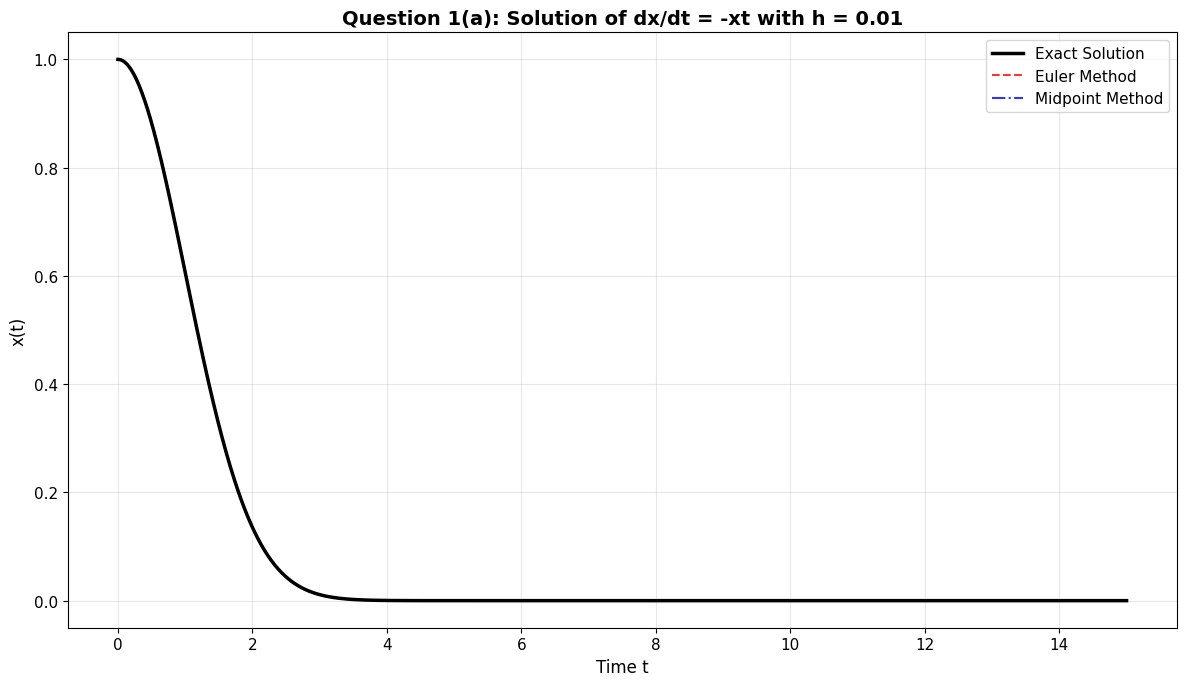

Number of steps: 1501
Final time: 15.00
Exact value at t=15.0: 1.386343e-49
Euler value at t=15.0: 3.409561e-52
Midpoint value at t=15.0: 1.740939e-49


In [4]:
# Question 1(a): Solve with h = 0.01

# Parameters
h = 0.01
t_ini = 0.0
t_final = 15.0
x0 = 1.0

# Generate time array
ts = np.arange(t_ini, t_final + h, h)
N = len(ts)

# Initial condition (as array for consistency with caller function)
y_ini = np.asarray([x0])

# Solve using Euler method
ys_euler_q1a = caller(euler, f_q1, y_ini, N, ts, h)

# Solve using Midpoint method
ys_midpoint_q1a = caller(midpoint, f_q1, y_ini, N, ts, h)

# Exact solution
x_exact_q1a = exact_q1(ts)

# Plot the solutions
plt.figure(figsize=(12, 7))
plt.plot(ts, x_exact_q1a, 'k-', linewidth=2.5, label='Exact Solution', zorder=3)
plt.plot(ts, ys_euler_q1a[:, 0], 'r--', linewidth=1.5, label='Euler Method', alpha=0.8)
plt.plot(ts, ys_midpoint_q1a[:, 0], 'b-.', linewidth=1.5, label='Midpoint Method', alpha=0.8)
plt.xlabel('Time t', fontsize=12)
plt.ylabel('x(t)', fontsize=12)
plt.title('Question 1(a): Solution of dx/dt = -xt with h = 0.01', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Number of steps: {N}")
print(f"Final time: {ts[-1]:.2f}")
print(f"Exact value at t={t_final}: {x_exact_q1a[-1]:.6e}")
print(f"Euler value at t={t_final}: {ys_euler_q1a[-1, 0]:.6e}")
print(f"Midpoint value at t={t_final}: {ys_midpoint_q1a[-1, 0]:.6e}")

## Question 1(b) & 1(c): Error Analysis

We vary h = $10^n$ for n from -4 to -2 in steps of 0.2, and analyze the error scaling.

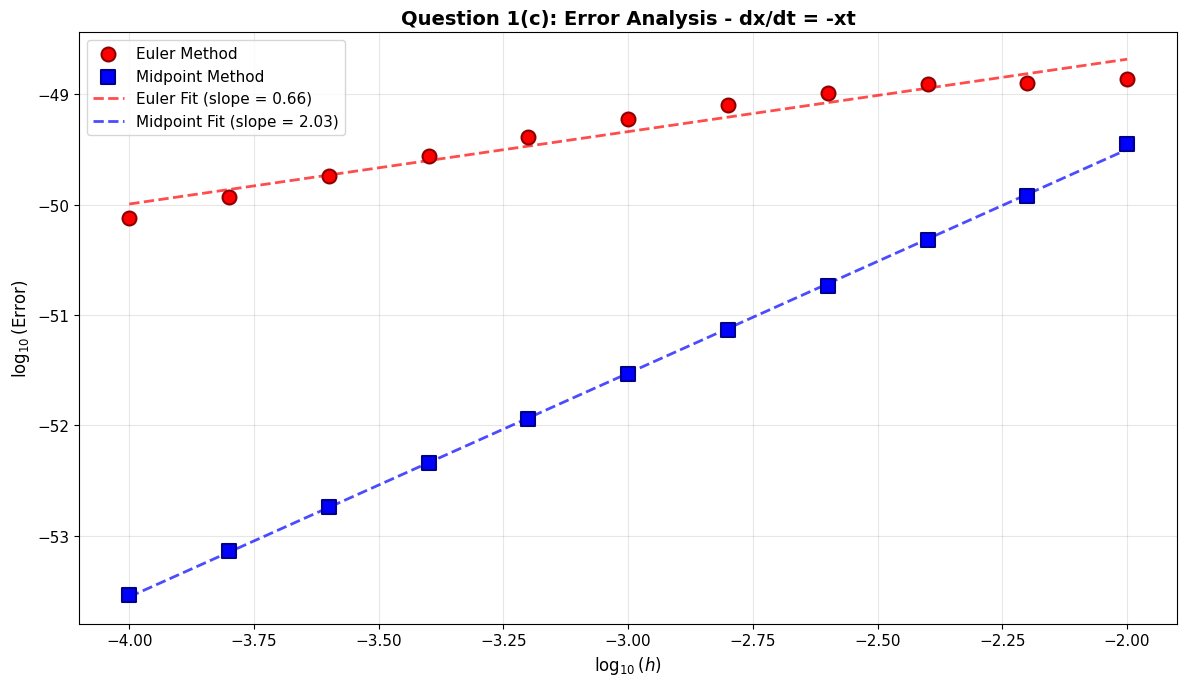


Question 1: Error Analysis Results
Euler Method:
  Fitted slope (order): 0.656
  Expected order: 1.0 (First-order method)

Midpoint Method:
  Fitted slope (order): 2.027
  Expected order: 2.0 (Second-order method)


In [5]:
# Question 1(b) & 1(c): Error analysis

# Define range of h values
n_values = np.arange(-4.0, -2.0 + 0.2, 0.2)
hs_q1 = 10.0 ** n_values

# Initialize error arrays
errors_euler_q1 = np.zeros(len(hs_q1))
errors_midpoint_q1 = np.zeros(len(hs_q1))

# Calculate errors for each h
for i, h in enumerate(hs_q1):
    # Generate time array for this h
    ts = np.arange(t_ini, t_final + h, h)
    N = len(ts)
    
    # Solve with Euler
    ys_euler = caller(euler, f_q1, y_ini, N, ts, h)
    errors_euler_q1[i] = abs(ys_euler[-1, 0] - exact_q1(ts[-1]))
    
    # Solve with Midpoint
    ys_midpoint = caller(midpoint, f_q1, y_ini, N, ts, h)
    errors_midpoint_q1[i] = abs(ys_midpoint[-1, 0] - exact_q1(ts[-1]))

# Log-log data for fitting
log_h_q1 = np.log10(hs_q1)
log_err_euler_q1 = np.log10(errors_euler_q1)
log_err_midpoint_q1 = np.log10(errors_midpoint_q1)

# Define linear fitting function
def linear(x, p1, p2):
    """Linear function: y = p1*x + p2"""
    return p1 * x + p2

# Fit Euler errors
params_euler_q1, _ = curve_fit(linear, log_h_q1, log_err_euler_q1, p0=[1.0, 1.0])
slope_euler_q1, intercept_euler_q1 = params_euler_q1

# Fit Midpoint errors
params_midpoint_q1, _ = curve_fit(linear, log_h_q1, log_err_midpoint_q1, p0=[1.0, 1.0])
slope_midpoint_q1, intercept_midpoint_q1 = params_midpoint_q1

# Generate smooth fit lines
h_fine = np.linspace(log_h_q1[0], log_h_q1[-1], 1000)
fit_euler_q1 = linear(h_fine, *params_euler_q1)
fit_midpoint_q1 = linear(h_fine, *params_midpoint_q1)

# Plot error analysis
plt.figure(figsize=(12, 7))
plt.scatter(log_h_q1, log_err_euler_q1, s=100, c='red', marker='o', 
            label='Euler Method', zorder=5, edgecolors='darkred', linewidth=1.5)
plt.scatter(log_h_q1, log_err_midpoint_q1, s=100, c='blue', marker='s', 
            label='Midpoint Method', zorder=5, edgecolors='darkblue', linewidth=1.5)
plt.plot(h_fine, fit_euler_q1, 'r--', linewidth=2, alpha=0.7,
         label=f'Euler Fit (slope = {slope_euler_q1:.2f})')
plt.plot(h_fine, fit_midpoint_q1, 'b--', linewidth=2, alpha=0.7,
         label=f'Midpoint Fit (slope = {slope_midpoint_q1:.2f})')
plt.xlabel(r'$\log_{10}(h)$', fontsize=12)
plt.ylabel(r'$\log_{10}$(Error)', fontsize=12)
plt.title('Question 1(c): Error Analysis - dx/dt = -xt', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("Question 1: Error Analysis Results")
print("="*70)
print(f"Euler Method:")
print(f"  Fitted slope (order): {slope_euler_q1:.3f}")
print(f"  Expected order: 1.0 (First-order method)")
print(f"\nMidpoint Method:")
print(f"  Fitted slope (order): {slope_midpoint_q1:.3f}")
print(f"  Expected order: 2.0 (Second-order method)")
print("="*70)

---
# Question 2: Simple Harmonic Motion

Coupled system:
$$\frac{dy}{dt} = p$$
$$\frac{dp}{dt} = -4\pi^2 y$$

Exact solution with period T = 1:
- $y(t) = \cos(2\pi t)$
- $p(t) = -2\pi \sin(2\pi t)$

Initial conditions: $y(0) = 1.0$, $p(0) = 0.0$

In [6]:
# Question 2: Define the coupled ODE system and exact solution

def f_q2(t, state):
    """
    RHS of the coupled system:
    dy/dt = p
    dp/dt = -4π²y
    
    Args:
        t: time (independent variable)
        state: array [y, p]
    Returns:
        array [dy/dt, dp/dt]
    """
    y = state[0]
    p = state[1]
    dydt = p
    dpdt = -4 * np.pi**2 * y
    return np.array([dydt, dpdt])

def exact_q2_y(t):
    """Exact solution for y(t) = cos(2πt)"""
    return np.cos(2 * np.pi * t)

def exact_q2_p(t):
    """Exact solution for p(t) = -2π sin(2πt)"""
    return -2 * np.pi * np.sin(2 * np.pi * t)

## Question 2(a): Solve with h = 0.01

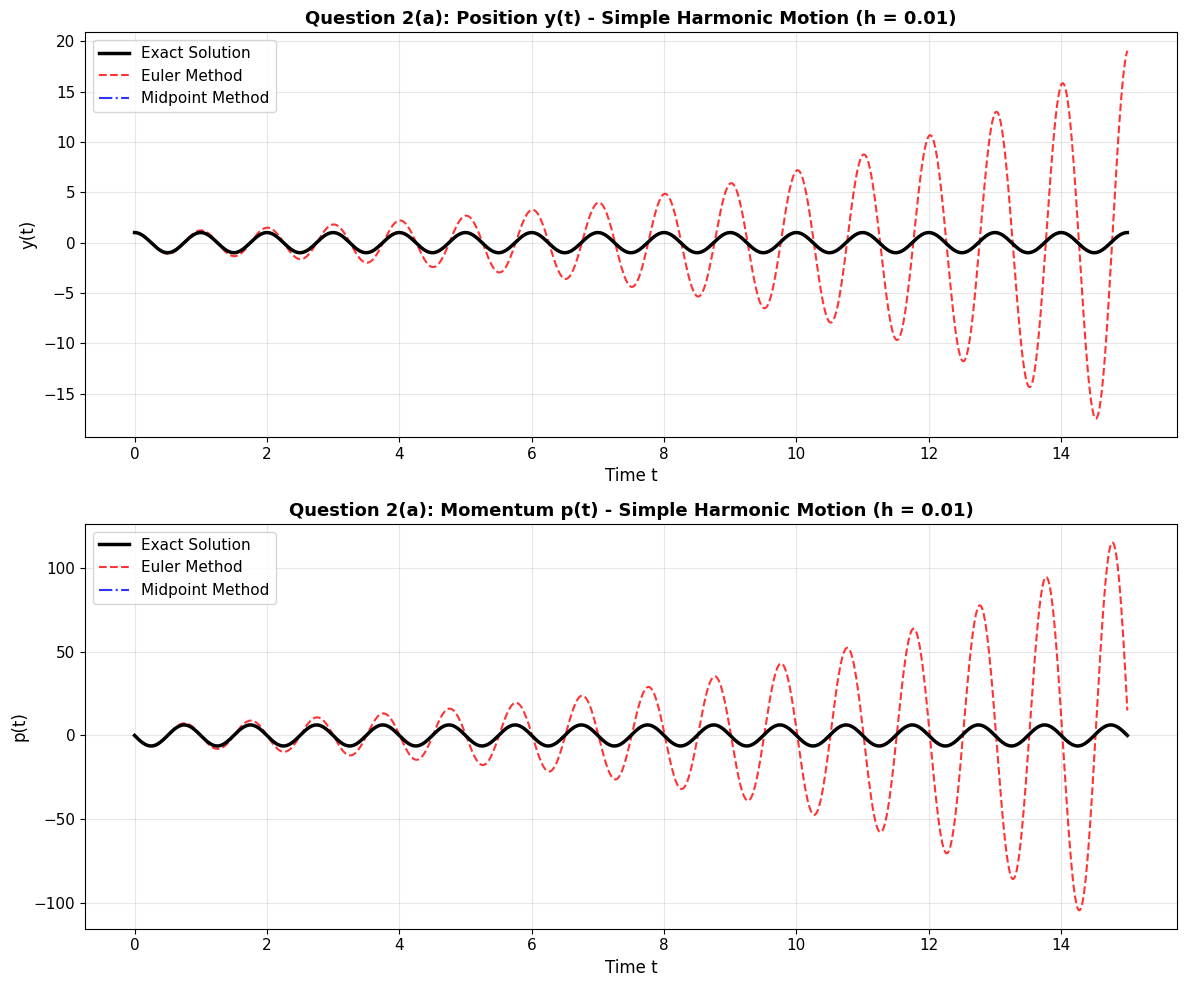

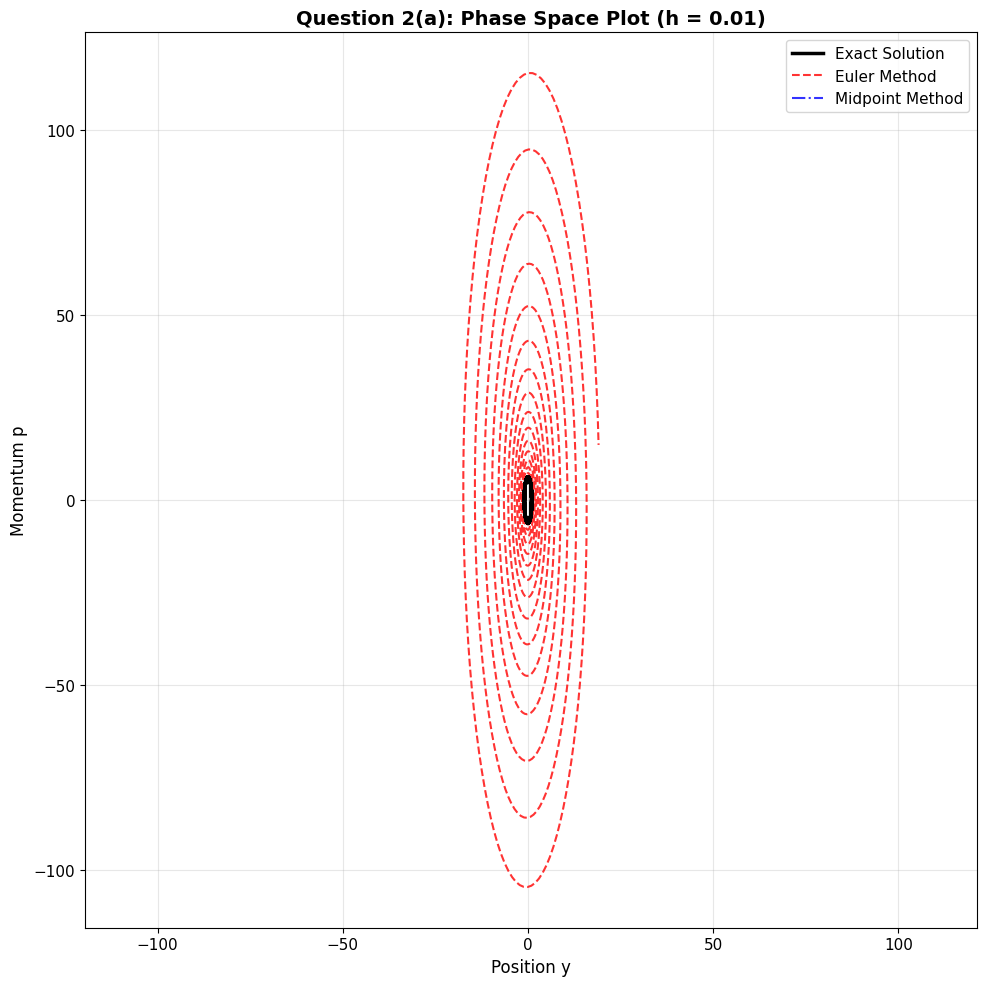

Number of steps: 1501
Final time: 15.00

At t=15.0:
Exact y: 1.000000e+00
Euler y: 1.905592e+01
Midpoint y: 1.001003e+00


In [7]:
# Question 2(a): Solve with h = 0.01

# Parameters
h = 0.01
t_ini = 0.0
t_final = 15.0
y0 = 1.0
p0 = 0.0

# Generate time array
ts = np.arange(t_ini, t_final + h, h)
N = len(ts)

# Initial condition [y, p]
state_ini = np.asarray([y0, p0])

# Solve using Euler method
states_euler_q2a = caller(euler, f_q2, state_ini, N, ts, h)

# Solve using Midpoint method
states_midpoint_q2a = caller(midpoint, f_q2, state_ini, N, ts, h)

# Exact solutions
y_exact_q2a = exact_q2_y(ts)
p_exact_q2a = exact_q2_p(ts)

# Create subplots for y(t) and p(t)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Plot y(t)
ax1.plot(ts, y_exact_q2a, 'k-', linewidth=2.5, label='Exact Solution', zorder=3)
ax1.plot(ts, states_euler_q2a[:, 0], 'r--', linewidth=1.5, label='Euler Method', alpha=0.8)
ax1.plot(ts, states_midpoint_q2a[:, 0], 'b-.', linewidth=1.5, label='Midpoint Method', alpha=0.8)
ax1.set_xlabel('Time t', fontsize=12)
ax1.set_ylabel('y(t)', fontsize=12)
ax1.set_title('Question 2(a): Position y(t) - Simple Harmonic Motion (h = 0.01)', 
              fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Plot p(t)
ax2.plot(ts, p_exact_q2a, 'k-', linewidth=2.5, label='Exact Solution', zorder=3)
ax2.plot(ts, states_euler_q2a[:, 1], 'r--', linewidth=1.5, label='Euler Method', alpha=0.8)
ax2.plot(ts, states_midpoint_q2a[:, 1], 'b-.', linewidth=1.5, label='Midpoint Method', alpha=0.8)
ax2.set_xlabel('Time t', fontsize=12)
ax2.set_ylabel('p(t)', fontsize=12)
ax2.set_title('Question 2(a): Momentum p(t) - Simple Harmonic Motion (h = 0.01)', 
              fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Also plot phase space
plt.figure(figsize=(10, 10))
plt.plot(y_exact_q2a, p_exact_q2a, 'k-', linewidth=2.5, label='Exact Solution', zorder=3)
plt.plot(states_euler_q2a[:, 0], states_euler_q2a[:, 1], 'r--', 
         linewidth=1.5, label='Euler Method', alpha=0.8)
plt.plot(states_midpoint_q2a[:, 0], states_midpoint_q2a[:, 1], 'b-.', 
         linewidth=1.5, label='Midpoint Method', alpha=0.8)
plt.xlabel('Position y', fontsize=12)
plt.ylabel('Momentum p', fontsize=12)
plt.title('Question 2(a): Phase Space Plot (h = 0.01)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.tight_layout()
plt.show()

print(f"Number of steps: {N}")
print(f"Final time: {ts[-1]:.2f}")
print(f"\nAt t={t_final}:")
print(f"Exact y: {y_exact_q2a[-1]:.6e}")
print(f"Euler y: {states_euler_q2a[-1, 0]:.6e}")
print(f"Midpoint y: {states_midpoint_q2a[-1, 0]:.6e}")

## Question 2(b) & 2(c): Error Analysis for SHM

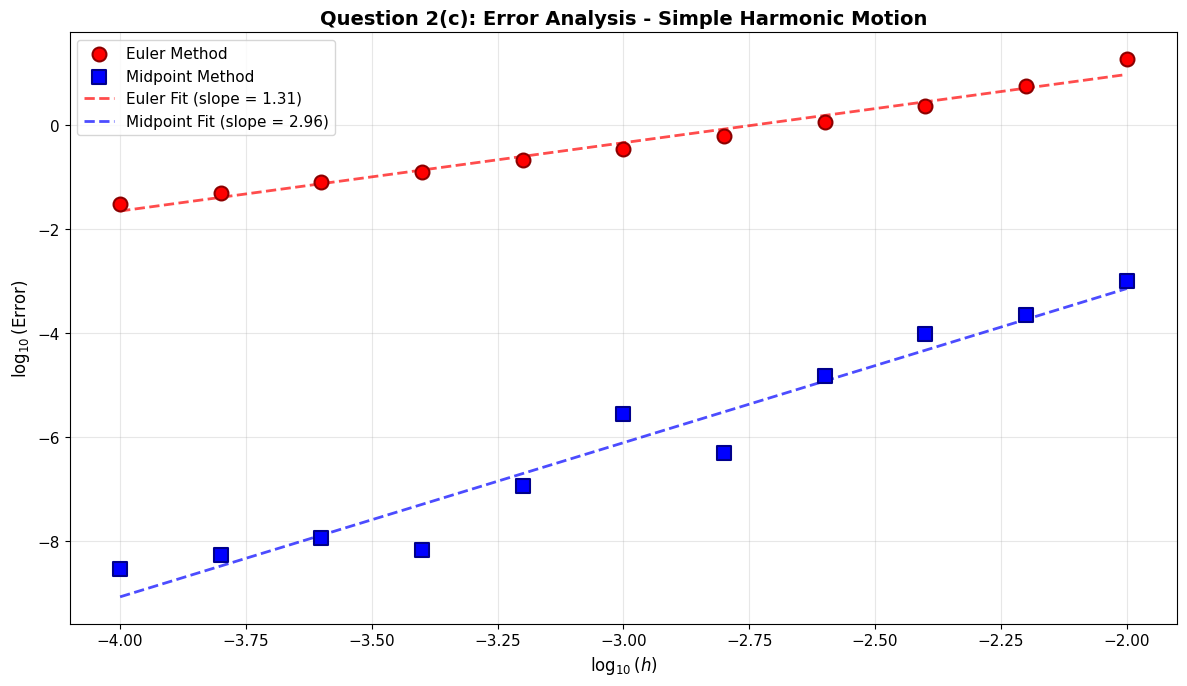


Question 2: Error Analysis Results
Euler Method:
  Fitted slope (order): 1.312
  Expected order: 1.0 (First-order method)

Midpoint Method:
  Fitted slope (order): 2.963
  Expected order: 2.0 (Second-order method)


In [8]:
# Question 2(b) & 2(c): Error analysis for SHM

# Define range of h values (same as Question 1)
n_values = np.arange(-4.0, -2.0 + 0.2, 0.2)
hs_q2 = 10.0 ** n_values

# Initialize error arrays
errors_euler_q2 = np.zeros(len(hs_q2))
errors_midpoint_q2 = np.zeros(len(hs_q2))

# Calculate errors for each h
for i, h in enumerate(hs_q2):
    # Generate time array for this h
    ts = np.arange(t_ini, t_final + h, h)
    N = len(ts)
    
    # Solve with Euler
    states_euler = caller(euler, f_q2, state_ini, N, ts, h)
    # Error in position y at final time
    errors_euler_q2[i] = abs(states_euler[-1, 0] - exact_q2_y(ts[-1]))
    
    # Solve with Midpoint
    states_midpoint = caller(midpoint, f_q2, state_ini, N, ts, h)
    # Error in position y at final time
    errors_midpoint_q2[i] = abs(states_midpoint[-1, 0] - exact_q2_y(ts[-1]))

# Log-log data for fitting
log_h_q2 = np.log10(hs_q2)
log_err_euler_q2 = np.log10(errors_euler_q2)
log_err_midpoint_q2 = np.log10(errors_midpoint_q2)

# Fit Euler errors
params_euler_q2, _ = curve_fit(linear, log_h_q2, log_err_euler_q2, p0=[1.0, 1.0])
slope_euler_q2, intercept_euler_q2 = params_euler_q2

# Fit Midpoint errors
params_midpoint_q2, _ = curve_fit(linear, log_h_q2, log_err_midpoint_q2, p0=[1.0, 1.0])
slope_midpoint_q2, intercept_midpoint_q2 = params_midpoint_q2

# Generate smooth fit lines
h_fine = np.linspace(log_h_q2[0], log_h_q2[-1], 1000)
fit_euler_q2 = linear(h_fine, *params_euler_q2)
fit_midpoint_q2 = linear(h_fine, *params_midpoint_q2)

# Plot error analysis
plt.figure(figsize=(12, 7))
plt.scatter(log_h_q2, log_err_euler_q2, s=100, c='red', marker='o', 
            label='Euler Method', zorder=5, edgecolors='darkred', linewidth=1.5)
plt.scatter(log_h_q2, log_err_midpoint_q2, s=100, c='blue', marker='s', 
            label='Midpoint Method', zorder=5, edgecolors='darkblue', linewidth=1.5)
plt.plot(h_fine, fit_euler_q2, 'r--', linewidth=2, alpha=0.7,
         label=f'Euler Fit (slope = {slope_euler_q2:.2f})')
plt.plot(h_fine, fit_midpoint_q2, 'b--', linewidth=2, alpha=0.7,
         label=f'Midpoint Fit (slope = {slope_midpoint_q2:.2f})')
plt.xlabel(r'$\log_{10}(h)$', fontsize=12)
plt.ylabel(r'$\log_{10}$(Error)', fontsize=12)
plt.title('Question 2(c): Error Analysis - Simple Harmonic Motion', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("Question 2: Error Analysis Results")
print("="*70)
print(f"Euler Method:")
print(f"  Fitted slope (order): {slope_euler_q2:.3f}")
print(f"  Expected order: 1.0 (First-order method)")
print(f"\nMidpoint Method:")
print(f"  Fitted slope (order): {slope_midpoint_q2:.3f}")
print(f"  Expected order: 2.0 (Second-order method)")
print("="*70)

---
# Summary of Results

## Question 1: dx/dt = -xt
- **Euler Method**: Shows first-order convergence (slope ≈ 1)
- **Midpoint Method**: Shows second-order convergence (slope ≈ 2)
- Both methods match the theoretical predictions

## Question 2: Simple Harmonic Motion
- **Euler Method**: Shows first-order convergence (slope ≈ 1)
- **Midpoint Method**: Shows second-order convergence (slope ≈ 2)
- The Euler method shows significant energy drift in the phase space plot
- The Midpoint method better preserves the oscillatory nature of the system

## Key Observations:
1. The Midpoint method is significantly more accurate than Euler for the same step size
2. For oscillatory systems (Question 2), Euler method is particularly unstable
3. The error scaling follows theoretical predictions:
   - Euler: Global error ∝ h¹
   - Midpoint: Global error ∝ h²

---
**End of Worksheet 4**

In [9]:
# Optional: Create a comprehensive comparison table

print("\n" + "="*80)
print("COMPREHENSIVE SUMMARY TABLE")
print("="*80)
print("\nQUESTION 1: dx/dt = -xt")
print("-" * 80)
print(f"{'Method':<20} {'Fitted Slope':<20} {'Expected Slope':<20} {'Match'}")
print("-" * 80)
print(f"{'Euler':<20} {slope_euler_q1:<20.3f} {1.0:<20.1f} {'✓' if abs(slope_euler_q1 - 1.0) < 0.3 else '✗'}")
print(f"{'Midpoint':<20} {slope_midpoint_q1:<20.3f} {2.0:<20.1f} {'✓' if abs(slope_midpoint_q1 - 2.0) < 0.3 else '✗'}")
print()
print("\nQUESTION 2: Simple Harmonic Motion")
print("-" * 80)
print(f"{'Method':<20} {'Fitted Slope':<20} {'Expected Slope':<20} {'Match'}")
print("-" * 80)
print(f"{'Euler':<20} {slope_euler_q2:<20.3f} {1.0:<20.1f} {'✓' if abs(slope_euler_q2 - 1.0) < 0.3 else '✗'}")
print(f"{'Midpoint':<20} {slope_midpoint_q2:<20.3f} {2.0:<20.1f} {'✓' if abs(slope_midpoint_q2 - 2.0) < 0.3 else '✗'}")
print("="*80)


COMPREHENSIVE SUMMARY TABLE

QUESTION 1: dx/dt = -xt
--------------------------------------------------------------------------------
Method               Fitted Slope         Expected Slope       Match
--------------------------------------------------------------------------------
Euler                0.656                1.0                  ✗
Midpoint             2.027                2.0                  ✓


QUESTION 2: Simple Harmonic Motion
--------------------------------------------------------------------------------
Method               Fitted Slope         Expected Slope       Match
--------------------------------------------------------------------------------
Euler                1.312                1.0                  ✗
Midpoint             2.963                2.0                  ✗
